# CMS Global Map Mangrove Canopy - Statistics Generation

Compares original GeoTIFF files with transformed COGs using chunked processing for memory efficiency.

Outputs:
- `detailed_stats.json` - Detailed statistics for each file
- `overall_stats.json` - Overall statistics for all 3 variables (agb, hmax95, hba95)

In [65]:
# Setup and Configuration
import os
import json
import boto3
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from pathlib import Path
import tempfile
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import gc
from tqdm import tqdm

load_dotenv()

# Configuration
reprocess = True  # Set to True to reprocess all files, False to load existing results
BUCKET_NAME = "ghgc-data-store-dev"
ORIGINAL_PREFIX = "coastal-observatory/data"
COG_PREFIX = "transformed_cogs/CMS_Global_Map_Mangrove_Canopy_Biomass"
VALID_DATA_TYPES = ["agb", "hmax95", "hba95"]
NODATA_VALUE = 0
DEFAULT_CHUNK_SIZE = 1024
output_dir = os.path.dirname(os.path.abspath("__file__"))

In [66]:
# S3 Helper Functions
def get_s3_client():
    return boto3.Session(
        aws_access_key_id=os.environ.get("AWS_ACCESS_KEY_ID"),
        aws_secret_access_key=os.environ.get("AWS_SECRET_ACCESS_KEY"),
        aws_session_token=os.environ.get("AWS_SESSION_TOKEN"),
        region_name="us-west-2"
    ).client("s3")

def list_s3_files(bucket, prefix, extension=".tif"):
    s3_client = get_s3_client()
    files = []
    paginator = s3_client.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        if "Contents" in page:
            files.extend([obj["Key"] for obj in page["Contents"] if obj["Key"].endswith(extension)])
    return sorted(files)

def download_s3_file(bucket, key, local_path):
    get_s3_client().download_file(bucket, key, local_path)

def extract_metadata_from_filename(filename):
    parts = Path(filename).stem.split("_")
    return {
        "data_type": parts[1] if len(parts) > 1 else "unknown",
        "region": "_".join(parts[2:]).replace("_2000year", "") if len(parts) > 2 else "unknown"
    }

In [67]:
# Chunked Statistics Computation
class IncrementalStats:
    def __init__(self):
        self.n = 0
        self.mean = 0.0
        self.M2 = 0.0
        self.min_val = float('inf')
        self.max_val = float('-inf')
    
    def update(self, values):
        if len(values) == 0:
            return
        self.min_val = min(self.min_val, np.nanmin(values))
        self.max_val = max(self.max_val, np.nanmax(values))
        for value in values:
            self.n += 1
            delta = value - self.mean
            self.mean += delta / self.n
            self.M2 += delta * (value - self.mean)
    
    def get_stats(self):
        if self.n == 0:
            return {"min": None, "max": None, "mean": None, "std": None, "count": 0}
        return {
            "min": float(self.min_val),
            "max": float(self.max_val),
            "mean": float(self.mean),
            "std": float(np.sqrt(self.M2 / self.n) if self.n > 1 else 0),
            "count": self.n
        }

def compute_raster_statistics_chunked(file_path):
    try:
        with rasterio.open(file_path) as src:
            width, height = src.width, src.height
            total_pixels = width * height
            chunk_size = min(DEFAULT_CHUNK_SIZE, width, height)
            
            stats_calc = IncrementalStats()
            valid_pixels = 0
            
            # Process in chunks
            for row_off in range(0, height, chunk_size):
                for col_off in range(0, width, chunk_size):
                    window = Window(col_off, row_off, 
                                  min(chunk_size, width - col_off),
                                  min(chunk_size, height - row_off))
                    chunk = src.read(1, window=window)
                    valid_mask = (chunk != NODATA_VALUE) & np.isfinite(chunk)
                    valid_data = chunk[valid_mask]
                    valid_pixels += np.sum(valid_mask)
                    if len(valid_data) > 0:
                        stats_calc.update(valid_data)
            
            stats = stats_calc.get_stats()
            stats.update({
                "valid_pixels": int(valid_pixels),
                "total_pixels": int(total_pixels),
                "coverage_percent": float(valid_pixels / total_pixels * 100),
                "crs": str(src.crs),
                "width": width,
                "height": height,
                "bounds": list(src.bounds)
            })
            return stats
    except Exception as e:
        return {"error": str(e)}

In [68]:
# File Processing Functions
def process_file_pair(original_key, cog_key, bucket):
    result = {
        "original_file": original_key,
        "cog_file": cog_key,
        "metadata": extract_metadata_from_filename(original_key)
    }
    
    with tempfile.TemporaryDirectory() as tmpdir:
        # Process original file
        original_path = os.path.join(tmpdir, "original.tif")
        download_s3_file(bucket, original_key, original_path)
        result["original_stats"] = compute_raster_statistics_chunked(original_path)
        
        # Process COG file
        if cog_key:
            cog_path = os.path.join(tmpdir, "cog.tif")
            download_s3_file(bucket, cog_key, cog_path)
            result["cog_stats"] = compute_raster_statistics_chunked(cog_path)
        else:
            result["cog_stats"] = None
    
    gc.collect()
    return result

def calculate_overall_statistics(results):
    overall_stats = {"original": {}, "cog": {}}
    
    for data_type in VALID_DATA_TYPES:
        for stat_type in ["original", "cog"]:
            values = {"mins": [], "maxs": [], "means": [], "stds": [], "counts": []}
            
            for result in results:
                if result["metadata"]["data_type"] == data_type:
                    stats_key = f"{stat_type}_stats"
                    if result.get(stats_key) and "mean" in result[stats_key]:
                        stats = result[stats_key]
                        values["mins"].append(stats["min"])
                        values["maxs"].append(stats["max"])
                        values["means"].append(stats["mean"])
                        values["stds"].append(stats["std"])
                        values["counts"].append(stats["count"])
            
            if values["means"]:
                total_pixels = sum(values["counts"])
                weighted_mean = sum(m * c for m, c in zip(values["means"], values["counts"])) / total_pixels
                
                # Calculate combined std
                pooled_var = sum((c-1)*s*s + c*(m-weighted_mean)**2 
                               for m, s, c in zip(values["means"], values["stds"], values["counts"]))
                combined_std = np.sqrt(pooled_var / (total_pixels - 1)) if total_pixels > 1 else 0
                
                overall_stats[stat_type][data_type] = {
                    "min_value": float(np.min(values["mins"])),
                    "max_value": float(np.max(values["maxs"])),
                    "mean_value": float(weighted_mean),
                    "std_value": float(combined_std)
                }
    
    return overall_stats

In [69]:
# Check for existing results and handle reprocess flag
results_loaded = False
overall_stats_loaded = False

# If reprocess is True, delete existing files and force reprocessing
if reprocess:
    print("Reprocess flag is True - deleting existing results...")
    for filename in ["detailed_stats.json", "overall_stats.json"]:
        filepath = os.path.join(output_dir, filename)
        if os.path.exists(filepath):
            os.remove(filepath)
            print(f"Deleted {filename}")
    print("Starting fresh processing...")
else:
    # Try to load existing results
    if os.path.exists(os.path.join(output_dir, "detailed_stats.json")):
        try:
            with open(os.path.join(output_dir, "detailed_stats.json"), 'r') as f:
                results = json.load(f)
            print(f"Loaded {len(results)} existing results")
            results_loaded = True
            
            # Load overall stats
            if os.path.exists(os.path.join(output_dir, "overall_stats.json")):
                with open(os.path.join(output_dir, "overall_stats.json"), 'r') as f:
                    lines = f.readlines()
                    if len(lines) >= 4:
                        raw_stats = json.loads(lines[1].strip())
                        cog_stats = json.loads(lines[3].strip())
                        overall_stats = {"original": raw_stats, "cog": cog_stats}
                        overall_stats_loaded = True
                        print("Loaded overall statistics")
        except Exception as e:
            print(f"Error loading existing results: {e}")
            print("Proceeding with normal processing...")
            results_loaded = False
    else:
        print("No existing results found - proceeding with processing...")

Reprocess flag is True - deleting existing results...
Deleted detailed_stats.json
Deleted overall_stats.json
Starting fresh processing...


In [70]:
# Main Processing
if not results_loaded:
    # List files
    print("Listing files...")
    original_files = [f for f in list_s3_files(BUCKET_NAME, ORIGINAL_PREFIX) 
                     if any(dt in f for dt in VALID_DATA_TYPES)]
    cog_files = list_s3_files(BUCKET_NAME, COG_PREFIX)
    print(f"Found {len(original_files)} original files and {len(cog_files)} COG files")
    
    # Process files
    results = []
    for idx, orig_file in enumerate(original_files, 1):
        print(f"\r[{idx}/{len(original_files)}] Processing {Path(orig_file).name}...", end="")
        
        # Find matching COG
        orig_meta = extract_metadata_from_filename(orig_file)
        cog_match = None
        for cog_file in cog_files:
            cog_meta = extract_metadata_from_filename(cog_file)
            if (cog_meta["data_type"] == orig_meta["data_type"] and 
                cog_meta["region"] == orig_meta["region"]):
                cog_match = cog_file
                break
        
        try:
            result = process_file_pair(orig_file, cog_match, BUCKET_NAME)
            results.append(result)
        except Exception as e:
            results.append({
                "original_file": orig_file,
                "cog_file": cog_match,
                "metadata": orig_meta,
                "error": str(e)
            })
    
    print(f"\nCompleted processing {len(results)} files")
    
    # Save detailed results
    with open(os.path.join(output_dir, "detailed_stats.json"), "w") as f:
        json.dump(results, f, indent=2)
    print("Saved detailed_stats.json")

Listing files...
Found 348 original files and 348 COG files
[348/348] Processing Mangrove_hmax95_Yemen.tif...una.tif..........tif...
Completed processing 348 files
Saved detailed_stats.json


In [71]:
# Calculate and save overall statistics
if 'overall_stats' not in locals() or not overall_stats_loaded:
    overall_stats = calculate_overall_statistics(results)
    
    # Save in special format
    with open(os.path.join(output_dir, "overall_stats.json"), "w") as f:
        f.write('"Stats for raw tif files."\n')
        json.dump(overall_stats["original"], f)
        f.write('\n"Stats for transformed COG files."\n')
        json.dump(overall_stats["cog"], f)
    print("Saved overall_stats.json")

# Display overall statistics
print("\n" + "="*60)
print("OVERALL STATISTICS")
print("="*60)
for stat_type, label in [("original", "Original TIF"), ("cog", "COG")]:
    print(f"\n{label} files:")
    for var_type in VALID_DATA_TYPES:
        if var_type in overall_stats[stat_type]:
            stats = overall_stats[stat_type][var_type]
            print(f"\n{var_type.upper()}:")
            for key, value in stats.items():
                print(f"  {key}: {value:.6f}")

Saved overall_stats.json

OVERALL STATISTICS

Original TIF files:

AGB:
  min_value: 0.284488
  max_value: 910.475891
  mean_value: 130.237788
  std_value: 108.868964

HMAX95:
  min_value: 0.848500
  max_value: 62.789001
  mean_value: 16.388412
  std_value: 11.190709

HBA95:
  min_value: 0.537700
  max_value: 39.789799
  mean_value: 10.468337
  std_value: 7.126196

COG files:

AGB:
  min_value: 0.284488
  max_value: 910.475891
  mean_value: 130.237788
  std_value: 108.868964

HMAX95:
  min_value: 0.848500
  max_value: 62.789001
  mean_value: 16.388412
  std_value: 11.190709

HBA95:
  min_value: 0.537700
  max_value: 39.789799
  mean_value: 10.468337
  std_value: 7.126196


In [72]:
# Generate summary statistics
summary = {
    "total_files": len(results),
    "by_data_type": {},
    "errors": sum(1 for r in results if "error" in r.get("original_stats", {}))
}

for data_type in VALID_DATA_TYPES:
    type_results = [r for r in results if r["metadata"]["data_type"] == data_type]
    summary["by_data_type"][data_type] = len(type_results)

print("\nSUMMARY:")
print(f"Total files processed: {summary['total_files']}")
print(f"Files with errors: {summary['errors']}")
print("\nBy data type:")
for dt, count in summary["by_data_type"].items():
    print(f"  {dt}: {count} files")


SUMMARY:
Total files processed: 348
Files with errors: 0

By data type:
  agb: 116 files
  hmax95: 116 files
  hba95: 116 files


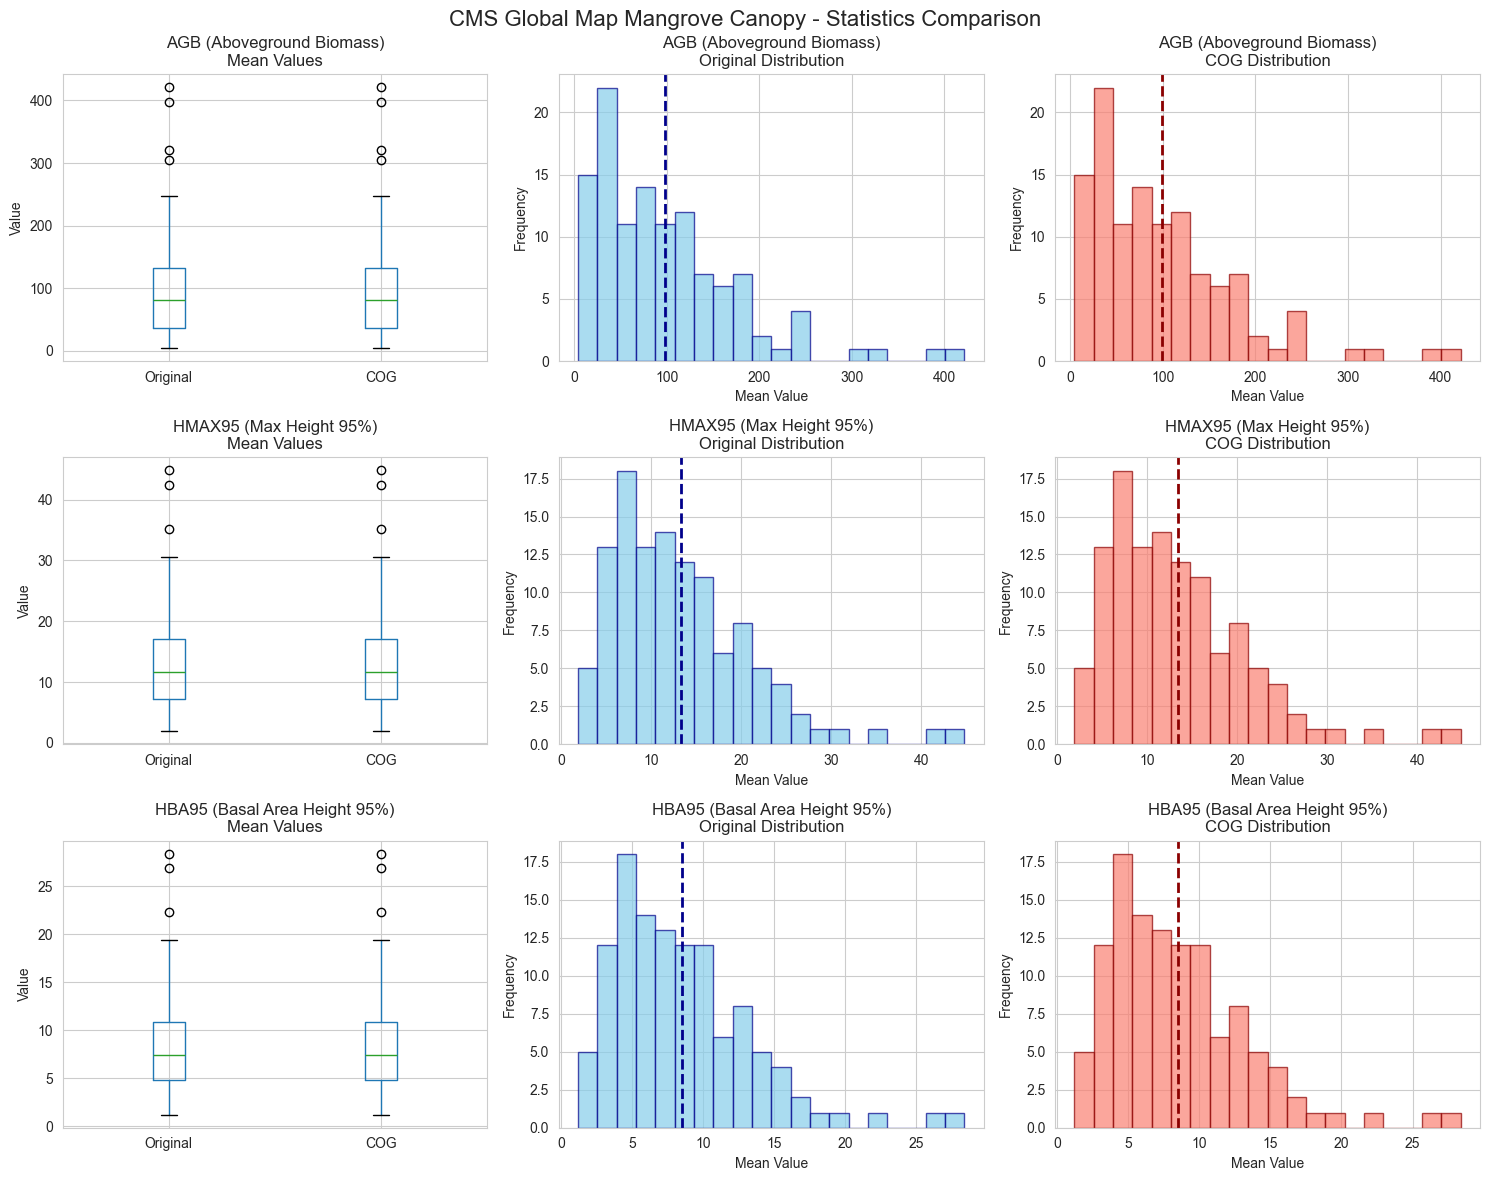

Saved statistics_comparison.png


In [73]:
# Create visualization
viz_data = {dt: {"original": {"means": [], "mins": [], "maxs": []}, 
                 "cog": {"means": [], "mins": [], "maxs": []}} 
            for dt in VALID_DATA_TYPES}

for result in results:
    if "error" not in result.get("original_stats", {}):
        dt = result["metadata"]["data_type"]
        if dt in viz_data and result["original_stats"].get("mean") is not None:
            for key in ["mean", "min", "max"]:
                viz_data[dt]["original"][f"{key}s"].append(result["original_stats"][key])
                if result.get("cog_stats") and result["cog_stats"].get(key) is not None:
                    viz_data[dt]["cog"][f"{key}s"].append(result["cog_stats"][key])

# Create figure
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("CMS Global Map Mangrove Canopy - Statistics Comparison", fontsize=16)

for idx, (var_type, var_label) in enumerate([
    ("agb", "AGB (Aboveground Biomass)"),
    ("hmax95", "HMAX95 (Max Height 95%)"),
    ("hba95", "HBA95 (Basal Area Height 95%)")
]):
    # Box plot comparison
    ax = axes[idx, 0]
    if viz_data[var_type]["original"]["means"] and viz_data[var_type]["cog"]["means"]:
        data = pd.DataFrame({
            "Original": viz_data[var_type]["original"]["means"],
            "COG": viz_data[var_type]["cog"]["means"]
        })
        data.boxplot(ax=ax)
        ax.set_title(f"{var_label}\nMean Values")
        ax.set_ylabel("Value")
    
    # Original histogram
    ax = axes[idx, 1]
    if viz_data[var_type]["original"]["means"]:
        ax.hist(viz_data[var_type]["original"]["means"], bins=20, 
                color='skyblue', edgecolor='darkblue', alpha=0.7)
        ax.axvline(np.mean(viz_data[var_type]["original"]["means"]), 
                  color='darkblue', linestyle='--', linewidth=2)
        ax.set_title(f"{var_label}\nOriginal Distribution")
        ax.set_xlabel("Mean Value")
        ax.set_ylabel("Frequency")
    
    # COG histogram
    ax = axes[idx, 2]
    if viz_data[var_type]["cog"]["means"]:
        ax.hist(viz_data[var_type]["cog"]["means"], bins=20, 
                color='salmon', edgecolor='darkred', alpha=0.7)
        ax.axvline(np.mean(viz_data[var_type]["cog"]["means"]), 
                  color='darkred', linestyle='--', linewidth=2)
        ax.set_title(f"{var_label}\nCOG Distribution")
        ax.set_xlabel("Mean Value")
        ax.set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "statistics_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved statistics_comparison.png")